# Initial comparision notebook


- set up one homogeneous `RSNN` and one heterogeneous `RSNN`
- train the homogeneous and heterogeneous models
- compute and plot the Gaussian $\mathcal{M}$-information comparison

In [2]:
from __future__ import annotations

import io
import sys
import random
from contextlib import contextmanager, redirect_stdout
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, rankdata

import torch

PROJECT_ROOT = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)")
WIMFO_ROOT = PROJECT_ROOT / "wimfo"
PAPER_ROOT = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from wimfo.W_M_Info import W_M_calculator
from wimfo.utils.utils_gauss import get_cov
from data_gen import open_file, sparse_data_generator
from reg_loss import loss as repo_loss
from SuSpike import SuSpike

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DT = 1e-3
SHD_TRAIN = PROJECT_ROOT / "data" / "shd" / "shd_train.h5"
SHD_TEST = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"
spike_fn = SuSpike.apply

print(f"Project root: {PROJECT_ROOT}")
print(f"wimfo root: {WIMFO_ROOT}")
print(f"Device: {DEVICE}")
print(f"Train file exists: {SHD_TRAIN.exists()}")
print(f"Test file exists: {SHD_TEST.exists()}")

Project root: C:\Users\Priya\Desktop\research project (SNN Info Theory)
wimfo root: C:\Users\Priya\Desktop\research project (SNN Info Theory)\wimfo
Device: cuda
Train file exists: True
Test file exists: True


## RSNN Setup

For our networks we copy the Perez-Nieves SHD `RSNN` code directly.


In [ ]:
import importlib

from clipper import ZeroOneClipper

RSNN = importlib.import_module("model").RSNN
clipper = ZeroOneClipper()

# Repo defaults copied from neural_heterogeneity/SuGD_code/main.py for SHD.
SHD_DEFAULTS = {
    "seed": 1000,
    "dtype": torch.float,
    "device": DEVICE,
    "cuda": DEVICE.type == "cuda",
    "nb_inputs": 700,
    "nb_hidden": [],
    "nb_recurrent": 128,
    "nb_outputs": 20,
    "batch_size": 64,
    "time_step": 0.5e-3,
    "nb_steps": 2000,
    # tau_syn: mean synaptic time constant (ms). Used to compute alpha = exp(-dt/tau_syn).
    # Controls how quickly the synaptic current decays between timesteps.
    "tau_syn": 10e-3,
    # tau_mem: mean membrane time constant (ms). Used to compute beta = exp(-dt/tau_mem).
    # Controls how quickly the membrane potential decays between timesteps.
    "tau_mem": 20e-3,
    "threshold": 1.0,
    "tref": 0.0,
    # dist: distribution family used to initialise heterogeneous tau values.
    # "gamma" is the paper default; shape parameter dist_prms=3.0 gives a spread
    # of tau_syn roughly 3–30 ms and tau_mem roughly 7–60 ms across 128 neurons.
    "dist": "gamma",
    "dist_prms": 3.0,
    "lr": 1e-3,
    # lr_ab: separate learning rate for the alpha and beta (tau) parameters.
    # Kept equal to lr here, matching the paper repo default.
    "lr_ab": 1e-3,
    "betas": (0.9, 0.999),
    "weight_decay": 0.0,
    "nb_epochs": 150,
    "drop_last": True,
    "sl": 0.0,
    "thetal": 0.0,
    "su": 0.0,
    "thetau": 0.0,
    "rate": 0.0,
    "p_del": 0.0,
    "train_th": 0,
    "het_th": 0,
    "train_reset": 0,
    "het_reset": 0,
    "train_rest": 0,
    "het_rest": 0,
    "sparse_data_generator": "sparse_data_generator",
    "time_scale": [0.5, 1.0],
    "model": "RSNN",
    "savestep": 10,
    "clip": 1,
    "plot_step": 50,
    "class_list": list(range(20)),
}

# Notebook-only overrides for this machine.
# This version increases training budget without changing the repo model or optimizer.
RUN_CONFIG = {
    "batch_size": 64,
    "nb_steps": 2000,
    "epochs": 15,  # repo nb_epochs = 150
    "train_batches_per_epoch": 30,  # repo trains on the full epoch with no batch cap
    "test_batches": None,  # None = full test set, matching the paper repo
    "m_subset_size": 6,  # repo training code has no notebook M-info subset parameter
    "m_batches": 3,  # repo training code has no notebook M-info batch cap
    "m_downsample_stride": 4,  # repo training code has no notebook M-info downsampling setting
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def decay_to_tau(decay: np.ndarray | float, dt: float) -> np.ndarray:
    # Inverts the decay formula: alpha = exp(-dt/tau) => tau = -dt / ln(alpha).
    # Used to convert learned alpha/beta values back into interpretable time constants (ms).
    decay = np.asarray(decay, dtype=np.float64)
    return -dt / np.log(decay)


@contextmanager
def shd_open(path: Path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()


# ── INTRODUCED: make_prms ───────────────────────────────────────────────────
#   alpha = exp(-dt / tau_syn),  beta = exp(-dt / tau_mem)
# make_prms controls which regime the model is built in by setting three flags:
#
#   heterogeneous=True  ->  het_ab=1, train_ab=1, train_hom_ab=0
#     Each of the 128 hidden neurons gets its own alpha_i and beta_i,
#     initialised by drawing tau values from a Gamma distribution
#     (shape k=3, mean=tau_syn/tau_mem) inside RecurrentSpikingLayer.__init__.
#     All 128 values are then learnable parameters updated by the optimiser.
#
#   heterogeneous=False ->  het_ab=0, train_ab=0, train_hom_ab=1
#     All neurons share one scalar alpha and one scalar beta, initialised
#     from the repo default tau_syn=10ms and tau_mem=20ms.
#     Only that single shared value is learnable.
#
# The three flags (het_ab, train_ab, train_hom_ab) are read directly by
# RecurrentSpikingLayer.__init__ in neural_heterogeneity/SuGD_code/layers.py.
# That is unchanged paper code — make_prms just sets those flags cleanly
# instead of scattering them across the notebook. Everything downstream
# runs the same paper code path regardless of which condition is chosen.
def make_prms(heterogeneous: bool, seed: int = 1000):
    prms = dict(SHD_DEFAULTS)
    prms.update({
        "seed": seed,
        "batch_size": RUN_CONFIG["batch_size"],
        "nb_steps": RUN_CONFIG["nb_steps"],
        "nb_epochs": RUN_CONFIG["epochs"],  # repo default nb_epochs = 150
    })
    # alpha: scalar decay factor for the synaptic current, derived from tau_syn.
    # alpha = exp(-dt / tau_syn). In the homogeneous case this is a single shared scalar.
    # In the heterogeneous case it is overwritten per-neuron inside RecurrentSpikingLayer.__init__.
    prms["alpha"] = float(np.exp(-prms["time_step"] / prms["tau_syn"]))
    # beta: scalar decay factor for the membrane potential, derived from tau_mem.
    # beta = exp(-dt / tau_mem). Same override logic as alpha above.
    prms["beta"] = float(np.exp(-prms["time_step"] / prms["tau_mem"]))

    # --- Heterogeneity control flags (the three-flag system from the paper repo) ---
    # het_ab=1: initialise each hidden neuron with its own alpha/beta drawn from the
    #           gamma distribution (shape=dist_prms, mean=tau_syn / tau_mem).
    #           het_ab=0 keeps all neurons at the same scalar alpha/beta.
    prms["het_ab"] = int(heterogeneous)
    # train_ab=1: make the per-neuron alpha and beta tensors (shape [1, nb_recurrent])
    #             learnable parameters. Only meaningful when het_ab=1.
    prms["train_ab"] = int(heterogeneous)
    # train_hom_ab=1: make the shared scalar alpha and beta (shape [1]) a learnable
    #                 parameter. Only used in the homogeneous control (het_ab=0).
    prms["train_hom_ab"] = int(not heterogeneous)
    return prms


def shd_generator(units, times, labels, prms: dict, shuffle: bool, epoch: int, drop_last: bool):
    yield from sparse_data_generator(
        units,
        times,
        labels,
        prms,
        shuffle=shuffle,
        epoch=epoch,
        drop_last=drop_last,
    )


def forward_logits(model, x):
    layer_recs = model(0, 0, x)
    output_layer = layer_recs[-1]
    logits, _ = torch.max(output_layer[1], dim=1)
    return logits, layer_recs


def get_hidden_ab_tensors(model):
    # Retrieves the alpha and beta tensors from the first (hidden recurrent) layer.
    # For heterogeneous models: shape [1, nb_recurrent] — one value per neuron.
    # For homogeneous models: shape [1] — one shared scalar broadcast across all neurons.
    hidden_layer = model.network[0]
    return hidden_layer.alpha.detach().clone(), hidden_layer.beta.detach().clone()


def summarize_hidden_taus(model, time_step: float):
    # Converts the learned alpha/beta decay values back to tau_syn / tau_mem in ms.
    # alpha_unique / beta_unique count distinct values: 128 = heterogeneous, 1 = homogeneous.
    hidden_layer = model.network[0]
    alpha = hidden_layer.alpha.detach().cpu().numpy().ravel()
    beta = hidden_layer.beta.detach().cpu().numpy().ravel()
    return {
        "alpha_unique": int(np.unique(np.round(alpha, 8)).size),
        "beta_unique": int(np.unique(np.round(beta, 8)).size),
        # tau_syn range reconstructed from alpha via: tau = -dt / ln(alpha)
        "tau_syn_ms_min": float(decay_to_tau(alpha, time_step).min() * 1e3),
        "tau_syn_ms_max": float(decay_to_tau(alpha, time_step).max() * 1e3),
        # tau_mem range reconstructed from beta
        "tau_mem_ms_min": float(decay_to_tau(beta, time_step).min() * 1e3),
        "tau_mem_ms_max": float(decay_to_tau(beta, time_step).max() * 1e3),
    }


def make_optimizer(model, prms: dict):
    # Separates weight parameters from alpha/beta (tau) parameters so they can
    # receive different learning rates (lr vs lr_ab), mirroring the paper repo optimizer.
    weight_params = []
    ab_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        # alpha and beta are the synaptic/membrane decay parameters (tau proxies)
        if "alpha" in name or "beta" in name:
            ab_params.append(param)
        else:
            weight_params.append(param)

    param_groups = [
        {
            "params": weight_params,
            "lr": prms["lr"],
            "weight_decay": prms["weight_decay"],
        }
    ]
    if ab_params:
        param_groups.append({"params": ab_params, "lr": prms["lr_ab"]})

    return torch.optim.Adam(param_groups, betas=prms["betas"])


def count_epoch_batches(path: Path, prms: dict):
    with shd_open(path) as (_, _, labels):
        sample_count = int(np.isin(labels[:], prms["class_list"]).sum())
    batch_size = int(prms["batch_size"])
    if prms["drop_last"]:
        return sample_count // batch_size
    return -(-sample_count // batch_size)


def count_epoch_samples(sample_count: int, batch_size: int, drop_last: bool, batch_limit: int | None = None):
    if drop_last:
        available_batches = sample_count // batch_size
    else:
        available_batches = -(-sample_count // batch_size)

    used_batches = available_batches if batch_limit is None else min(available_batches, int(batch_limit))

    if drop_last:
        return used_batches * batch_size

    remaining = sample_count
    used_samples = 0
    for _ in range(used_batches):
        take = min(batch_size, remaining)
        used_samples += take
        remaining -= take
    return used_samples


@torch.no_grad()
def evaluate_batches(
    model,
    prms: dict,
    units,
    times,
    labels,
    max_batches: int | None = None,
    num_samples: int | None = None,
    ):
    if num_samples is None:
        total_samples = int(np.isin(labels[:], prms["class_list"]).sum())
        num_samples = count_epoch_samples(
            total_samples,
            batch_size=int(prms["batch_size"]),
            drop_last=False,
            batch_limit=max_batches,
        )

    model.eval()
    batch_loss = 0.0
    batch_acc = 0

    for batch_index, (x, y) in enumerate(
        shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)
    ):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits, layer_recs = forward_logits(model, x)
        loss_val = repo_loss(logits, layer_recs, y, num_samples, prms)
        batch_loss += loss_val.item()
        batch_acc += (logits.argmax(dim=1) == y).sum().item()

    return {
        "loss": batch_loss,
        "acc": batch_acc / max(num_samples, 1),
        "n": num_samples,
    }


def train_experiment(model, prms: dict, train_path: Path, test_path: Path):
    optimizer = make_optimizer(model, prms)
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    # Notebook differences from repo training loop:
    # - optionally stop after a limited number of train batches per epoch
    # - optionally stop after a limited number of test batches
    train_batches_per_epoch = RUN_CONFIG.get("train_batches_per_epoch")
    test_batches = RUN_CONFIG.get("test_batches")

    with shd_open(train_path) as (units_train, times_train, labels_train), shd_open(test_path) as (units_test, times_test, labels_test):
        if not prms["class_list"]:
            prms["class_list"] = np.unique(labels_train[:]).tolist()

        total_train_samples = int(np.isin(labels_train[:], prms["class_list"]).sum())
        total_test_samples = int(np.isin(labels_test[:], prms["class_list"]).sum())
        effective_train_samples = count_epoch_samples(
            total_train_samples,
            batch_size=int(prms["batch_size"]),
            drop_last=bool(prms["drop_last"]),
            batch_limit=train_batches_per_epoch,
        )
        effective_test_samples = count_epoch_samples(
            total_test_samples,
            batch_size=int(prms["batch_size"]),
            drop_last=False,
            batch_limit=test_batches,
        )

        if prms["clip"]:
            # ZeroOneClipper clamps alpha and beta to [0, 1] after every gradient step,
            # ensuring the decay values remain valid (negative or >1 would be unphysical).
            model.apply(clipper)

        for epoch in range(1, prms["nb_epochs"] + 1):
            model.train()
            batch_train_loss = 0.0
            batch_train_acc = 0

            for batch_index, (x, y) in enumerate(
                shd_generator(
                    units_train,
                    times_train,
                    labels_train,
                    prms,
                    shuffle=True,
                    epoch=epoch,
                    drop_last=prms["drop_last"],
                )
            ):
                if train_batches_per_epoch is not None and batch_index >= train_batches_per_epoch:
                    break

                x = x.to(DEVICE)
                y = y.to(DEVICE)

                optimizer.zero_grad()
                logits, layer_recs = forward_logits(model, x)
                loss_val = repo_loss(logits, layer_recs, y, effective_train_samples, prms)
                loss_val.backward()
                optimizer.step()

                if prms["clip"]:
                    # Re-clip alpha/beta after each gradient step (paper repo behaviour).
                    model.apply(clipper)

                batch_train_loss += loss_val.item()
                batch_train_acc += (logits.argmax(dim=1) == y).sum().item()

            train_loss = batch_train_loss
            train_acc = batch_train_acc / max(effective_train_samples, 1)
            test_metrics = evaluate_batches(
                model,
                prms=prms,
                units=units_test,
                times=times_test,
                labels=labels_test,
                max_batches=test_batches,
                num_samples=effective_test_samples,
            )

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_metrics["loss"])
            history["test_acc"].append(test_metrics["acc"])

            print(
                f"epoch={epoch:03d} "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
                f"test_loss={test_metrics['loss']:.4f} test_acc={test_metrics['acc']:.3f}"
            )

    return history


@torch.no_grad()
def evaluate_model(model, prms: dict, path: Path, max_batches: int | None = None):
    with shd_open(path) as (units, times, labels):
        total_samples = int(np.isin(labels[:], prms["class_list"]).sum())
        effective_samples = count_epoch_samples(
            total_samples,
            batch_size=int(prms["batch_size"]),
            drop_last=False,
            batch_limit=max_batches,
        )
        return evaluate_batches(
            model,
            prms=prms,
            units=units,
            times=times,
            labels=labels,
            max_batches=max_batches,
            num_samples=effective_samples,
        )


def select_hidden_subset(nb_hidden: int, subset_size: int = 8) -> np.ndarray:
    subset_size = min(subset_size, nb_hidden)
    return np.linspace(0, nb_hidden - 1, subset_size, dtype=int)


def gaussian_copula_normalize(data: np.ndarray) -> np.ndarray:
    transformed = np.zeros_like(data, dtype=np.float64)
    for index, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks = rankdata(row, method="average")
        uniform = (ranks - 0.5) / len(row)
        uniform = np.clip(uniform, 1e-6, 1.0 - 1e-6)
        transformed[index] = norm.ppf(uniform)
    return transformed


def regularize_covariance(cov: np.ndarray, ridge: float = 1e-2) -> np.ndarray:
    cov = np.asarray(cov, dtype=np.float64)
    cov = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if not np.isfinite(scale) or scale <= 0.0:
        scale = 1.0
    return cov + ridge * scale * np.eye(cov.shape[0], dtype=np.float64)


@torch.no_grad()
def collect_hidden_state_matrix(
    model,
    prms: dict,
    path: Path,
    max_batches: int = 2,
    subset_size: int = 6,
    downsample_stride: int = 4,
    state_index: int = 0,
    state_key_index: int = 1,
    ):
    with shd_open(path) as (units, times, labels):
        hidden_size = int(model.network[0].output_size)
        chosen = select_hidden_subset(hidden_size, subset_size=subset_size)
        stride = max(int(downsample_stride), 1)
        chunks = []

        for batch_index, (x, _) in enumerate(
            shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)
        ):
            if batch_index >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            hidden_mem = layer_recs[state_index][state_key_index][:, ::stride, :][:, :, chosen].detach().cpu().numpy()
            hidden_mem = np.transpose(hidden_mem, (2, 0, 1)).reshape(len(chosen), -1)
            chunks.append(hidden_mem)

    if not chunks:
        raise RuntimeError("No SHD batches were collected for M-information estimation.")

    return np.concatenate(chunks, axis=1)


def estimate_m_info(
    model,
    prms: dict,
    path: Path,
    subset_size: int = 6,
    max_batches: int = 2,
    lag: int = 1,
    downsample_stride: int = 4,
    ):
    candidate_sizes = []
    for value in [subset_size, 4, 3, 2]:
        if value > 0 and value not in candidate_sizes:
            candidate_sizes.append(value)

    candidate_strides = []
    # Notebook difference from the repo: M-info is estimated on a smaller
    # hidden subset and optionally time-downsampled membrane trajectories so
    # the estimator fits within local runtime and memory limits.
    for value in [downsample_stride, downsample_stride * 2, 1]:
        value = max(int(value), 1)
        if value not in candidate_strides:
            candidate_strides.append(value)

    last_error = None
    for candidate_size in candidate_sizes:
        for candidate_stride in candidate_strides:
            hidden_data = collect_hidden_state_matrix(
                model,
                prms=prms,
                path=path,
                max_batches=max_batches,
                subset_size=candidate_size,
                downsample_stride=candidate_stride,
            )
            gaussian_data = gaussian_copula_normalize(hidden_data)
            lagged_cov = regularize_covariance(get_cov(gaussian_data, t=lag), ridge=1e-2)
            for optimiser, options in [
                ("Newton", None),
                ("Adam", {"atol": 1e-4, "rtol": 1e-4}),
            ]:
                try:
                    with io.StringIO() as buffer, redirect_stdout(buffer):
                        W_bits, M_bits = W_M_calculator(
                            lagged_cov,
                            option="distr",
                            type="gaussian",
                            unit="bits",
                            verbose=False,
                            optimiser=optimiser,
                            options=options,
                        )
                except Exception as exc:
                    last_error = exc
                    continue

                if np.isfinite(W_bits) and np.isfinite(M_bits):
                    return {
                        "W_bits": float(W_bits),
                        "M_bits": float(M_bits),
                        "subset_size": int(candidate_size),
                        "samples": int(gaussian_data.shape[1]),
                        "downsample_stride": int(candidate_stride),
                        "optimiser": optimiser,
                    }

    if last_error is not None:
        raise RuntimeError("M-information estimation failed after trying smaller subsets and optimisers.") from last_error
    raise RuntimeError("M-information estimation returned NaN for every tested configuration.")


print("Repo defaults:", {
    "batch_size": SHD_DEFAULTS["batch_size"],
    "nb_epochs": SHD_DEFAULTS["nb_epochs"],
    "nb_steps": SHD_DEFAULTS["nb_steps"],

    "time_step": SHD_DEFAULTS["time_step"],

    "lr": SHD_DEFAULTS["lr"],print("Active run config:", RUN_CONFIG)

    "lr_ab": SHD_DEFAULTS["lr_ab"],})

    "dist": SHD_DEFAULTS["dist"],    "dist_prms": SHD_DEFAULTS["dist_prms"],

Repo defaults: {'batch_size': 64, 'nb_epochs': 150, 'nb_steps': 2000, 'time_step': 0.0005, 'lr': 0.001, 'lr_ab': 0.001, 'dist': 'gamma', 'dist_prms': 3.0}
Active run config: {'batch_size': 64, 'nb_steps': 2000, 'epochs': 15, 'train_batches_per_epoch': 30, 'test_batches': None, 'm_subset_size': 6, 'm_batches': 3, 'm_downsample_stride': 4}


In [ ]:
# ── FIRST CALL: make_prms ────────────────────────────────────────────────────
# make_prms is called here (defined in the cell above) to build the parameter
# dicts for both conditions. Passing heterogeneous=False/True is the only
# difference needed — all other hyperparameters come from SHD_DEFAULTS and
# RUN_CONFIG, ensuring a controlled comparison.
homogeneous_prms = make_prms(heterogeneous=False, seed=1000)
heterogeneous_prms = make_prms(heterogeneous=True, seed=1000)

# Both models use the same seed and architecture (128 recurrent neurons, 700 inputs, 20 outputs).
# The only difference between them is the three heterogeneity flags set by make_prms():
#   homogeneous:  het_ab=0, train_ab=0, train_hom_ab=1
#     -> alpha and beta are a single shared scalar [1], initialised to exp(-dt/tau_syn/tau_mem)
#   heterogeneous: het_ab=1, train_ab=1, train_hom_ab=0
#     -> alpha and beta are per-neuron tensors [1, 128], each drawn from Gamma(k=3, mean=tau_syn/tau_mem)
#        inside RecurrentSpikingLayer.__init__ in layers.py

# --- Heterogeneity initialisation point ---
# set_seed before model construction ensures the gamma draws for alpha/beta are reproducible.
set_seed(homogeneous_prms["seed"])
homogeneous_model = RSNN(homogeneous_prms, rec=True).to(DEVICE)
set_seed(heterogeneous_prms["seed"])
# RecurrentSpikingLayer.__init__ reads het_ab=1 here and replaces the scalar alpha/beta
# with per-neuron values: alpha_i = exp(-dt / Gamma(k=3, mean=tau_syn)), same for beta_i.
heterogeneous_model = RSNN(heterogeneous_prms, rec=True).to(DEVICE)

# Snapshot alpha and beta before training, so we can measure how much they move.
# For the homogeneous model both tensors are shape [1] (one shared value).
# For the heterogeneous model both tensors are shape [1, 128] (one per neuron).
homogeneous_alpha_before, homogeneous_beta_before = get_hidden_ab_tensors(homogeneous_model)
heterogeneous_alpha_before, heterogeneous_beta_before = get_hidden_ab_tensors(heterogeneous_model)

# Summarise the initial tau distributions.
# Heterogeneous model: alpha_unique=128 and beta_unique=128 confirms per-neuron initialisation.
# Homogeneous model: alpha_unique=1 and beta_unique=1 confirms a single shared value.
# tau_syn_ms and tau_mem_ms are recovered via tau = -dt / ln(alpha/beta).
homogeneous_before = summarize_hidden_taus(homogeneous_model, homogeneous_prms["time_step"])
heterogeneous_before = summarize_hidden_taus(heterogeneous_model, heterogeneous_prms["time_step"])

train_batches_per_epoch = count_epoch_batches(SHD_TRAIN, homogeneous_prms)
repo_audit = {
    "repo_defaults": {
        "batch_size": SHD_DEFAULTS["batch_size"],
        "nb_epochs": SHD_DEFAULTS["nb_epochs"],
        "nb_steps": SHD_DEFAULTS["nb_steps"],
        "time_step": SHD_DEFAULTS["time_step"],
        "lr": SHD_DEFAULTS["lr"],
        "lr_ab": SHD_DEFAULTS["lr_ab"],
    },
    "active_run": {
        "batch_size": homogeneous_prms["batch_size"],
        "nb_epochs": homogeneous_prms["nb_epochs"],
        "nb_steps": homogeneous_prms["nb_steps"],
        "time_step": homogeneous_prms["time_step"],
        "lr": homogeneous_prms["lr"],
        "lr_ab": homogeneous_prms["lr_ab"],
    },
    "train_batches_per_epoch": train_batches_per_epoch,
}

training_results = {}


print("Homogeneous initial taus:", homogeneous_before)

print("Heterogeneous initial taus:", heterogeneous_before)print("Setup complete.")
print(repo_audit)

Homogeneous initial taus: {'alpha_unique': 1, 'beta_unique': 1, 'tau_syn_ms_min': 10.000006010359865, 'tau_syn_ms_max': 10.000006010359865, 'tau_mem_ms_min': 19.999997015687487, 'tau_mem_ms_max': 19.999997015687487}
Heterogeneous initial taus: {'alpha_unique': 128, 'beta_unique': 128, 'tau_syn_ms_min': 0.5985968411043763, 'tau_syn_ms_max': 25.321628808929, 'tau_mem_ms_min': 2.6563055528094828, 'tau_mem_ms_max': 49.25624591247297}
{'repo_defaults': {'batch_size': 64, 'nb_epochs': 150, 'nb_steps': 2000, 'time_step': 0.0005, 'lr': 0.001, 'lr_ab': 0.001}, 'active_run': {'batch_size': 64, 'nb_epochs': 15, 'nb_steps': 2000, 'time_step': 0.0005, 'lr': 0.001, 'lr_ab': 0.001}, 'train_batches_per_epoch': 127}
Setup complete. Run the next two training cells independently.


In [ ]:
required_names = [
    "homogeneous_model",
    "homogeneous_prms",
    "homogeneous_alpha_before",
    "homogeneous_beta_before",
    "homogeneous_before",
    "training_results",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError("Need to run set up")

homogeneous_history = train_experiment(
    homogeneous_model,
    prms=homogeneous_prms,
    train_path=SHD_TRAIN,
    test_path=SHD_TEST,
)

homogeneous_eval = evaluate_model(
    homogeneous_model,
    homogeneous_prms,
    SHD_TEST,
    max_batches=RUN_CONFIG["test_batches"],
)

# Summarise the final tau distributions after training.
# For the homogeneous model, alpha_unique and beta_unique remain 1 (the shared scalar moved).
# tau_syn_ms and tau_mem_ms show the single time constant to which the model converged.
homogeneous_after = summarize_hidden_taus(
    homogeneous_model,
    homogeneous_prms["time_step"],
)
# Retrieve the final alpha (tau_syn proxy) and beta (tau_mem proxy) tensors post-training.
homogeneous_alpha_after, homogeneous_beta_after = get_hidden_ab_tensors(homogeneous_model)

training_results["homogeneous"] = {
    "test_acc": homogeneous_eval["acc"],
    # mean_abs_alpha_change: average absolute shift in alpha (tau_syn decay) over training.
    # Non-zero confirms that the shared alpha was a learnable parameter (train_hom_ab=1).
    "mean_abs_alpha_change": float((homogeneous_alpha_after - homogeneous_alpha_before).abs().mean().item()),
    # mean_abs_beta_change: same diagnostic for beta (tau_mem decay).
    "mean_abs_beta_change": float((homogeneous_beta_after - homogeneous_beta_before).abs().mean().item()),
    "initial_summary": homogeneous_before,
    "final_summary": homogeneous_after,
}

print({"homogeneous": training_results["homogeneous"]})


epoch=001 train_loss=2.9369 train_acc=0.116 test_loss=2.8376 test_acc=0.149
epoch=002 train_loss=2.7391 train_acc=0.177 test_loss=2.6378 test_acc=0.220
epoch=003 train_loss=2.5499 train_acc=0.229 test_loss=2.3773 test_acc=0.272
epoch=004 train_loss=2.2974 train_acc=0.283 test_loss=2.1422 test_acc=0.355
epoch=005 train_loss=2.1005 train_acc=0.350 test_loss=1.9715 test_acc=0.388
epoch=006 train_loss=1.8595 train_acc=0.393 test_loss=1.8900 test_acc=0.380
epoch=007 train_loss=1.6825 train_acc=0.413 test_loss=1.6726 test_acc=0.409
epoch=008 train_loss=1.5596 train_acc=0.469 test_loss=1.5392 test_acc=0.485
epoch=009 train_loss=1.4335 train_acc=0.509 test_loss=1.4385 test_acc=0.513
epoch=010 train_loss=1.3392 train_acc=0.529 test_loss=1.4984 test_acc=0.492
epoch=011 train_loss=1.3478 train_acc=0.527 test_loss=1.4242 test_acc=0.507
epoch=012 train_loss=1.4847 train_acc=0.482 test_loss=1.3146 test_acc=0.565
epoch=013 train_loss=1.3051 train_acc=0.536 test_loss=1.3997 test_acc=0.529
epoch=014 tr

In [9]:
required_names = [
    "heterogeneous_model",
    "heterogeneous_prms",
    "heterogeneous_alpha_before",
    "heterogeneous_beta_before",
    "heterogeneous_before",
    "training_results",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError("Run the setup cell before starting heterogeneous training.")

heterogeneous_history = train_experiment(
    heterogeneous_model,
    prms=heterogeneous_prms,
    train_path=SHD_TRAIN,
    test_path=SHD_TEST,
)

heterogeneous_eval = evaluate_model(
    heterogeneous_model,
    heterogeneous_prms,
    SHD_TEST,
    max_batches=RUN_CONFIG["test_batches"],
)

# Summarise the final tau distributions after training.
# For the heterogeneous model, alpha_unique and beta_unique should remain 128 (each neuron
# converged to a different value), and the tau_syn_ms / tau_mem_ms range reflects
# how far the per-neuron time constants drifted from their gamma-initialised values.
heterogeneous_after = summarize_hidden_taus(
    heterogeneous_model,
    heterogeneous_prms["time_step"],
)
# Retrieve the final per-neuron alpha (tau_syn proxy) and beta (tau_mem proxy) tensors.
# Shape: [1, 128] — one learned decay value per hidden neuron.
heterogeneous_alpha_after, heterogeneous_beta_after = get_hidden_ab_tensors(heterogeneous_model)

training_results["heterogeneous"] = {
    "test_acc": heterogeneous_eval["acc"],
    # mean_abs_alpha_change: average absolute shift across all 128 per-neuron alpha values.
    # Large values indicate the heterogeneous tau_syn distribution moved significantly during training.
    "mean_abs_alpha_change": float((heterogeneous_alpha_after - heterogeneous_alpha_before).abs().mean().item()),
    # mean_abs_beta_change: same diagnostic for the 128 per-neuron beta (tau_mem) values.
    "mean_abs_beta_change": float((heterogeneous_beta_after - heterogeneous_beta_before).abs().mean().item()),
    "initial_summary": heterogeneous_before,
    "final_summary": heterogeneous_after,
}

print({"heterogeneous": training_results["heterogeneous"]})


epoch=001 train_loss=2.9509 train_acc=0.094 test_loss=2.8825 test_acc=0.095
epoch=002 train_loss=2.7811 train_acc=0.150 test_loss=2.7033 test_acc=0.188
epoch=003 train_loss=2.6384 train_acc=0.203 test_loss=2.5561 test_acc=0.218
epoch=004 train_loss=2.4107 train_acc=0.248 test_loss=2.3096 test_acc=0.258
epoch=005 train_loss=2.2001 train_acc=0.288 test_loss=2.2900 test_acc=0.272
epoch=006 train_loss=2.0318 train_acc=0.336 test_loss=2.0276 test_acc=0.375
epoch=007 train_loss=1.7838 train_acc=0.406 test_loss=1.7498 test_acc=0.399
epoch=008 train_loss=1.6096 train_acc=0.447 test_loss=1.4895 test_acc=0.518
epoch=009 train_loss=1.3801 train_acc=0.532 test_loss=1.4485 test_acc=0.492
epoch=010 train_loss=1.3544 train_acc=0.520 test_loss=1.3529 test_acc=0.517
epoch=011 train_loss=1.2375 train_acc=0.553 test_loss=1.2541 test_acc=0.550
epoch=012 train_loss=1.1017 train_acc=0.618 test_loss=1.1269 test_acc=0.600
epoch=013 train_loss=1.0753 train_acc=0.614 test_loss=1.1267 test_acc=0.622
epoch=014 tr

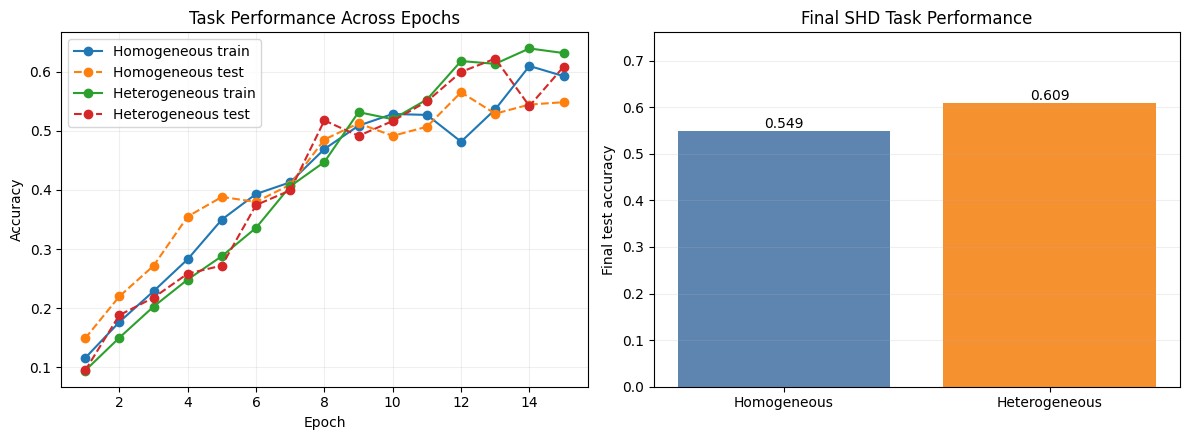

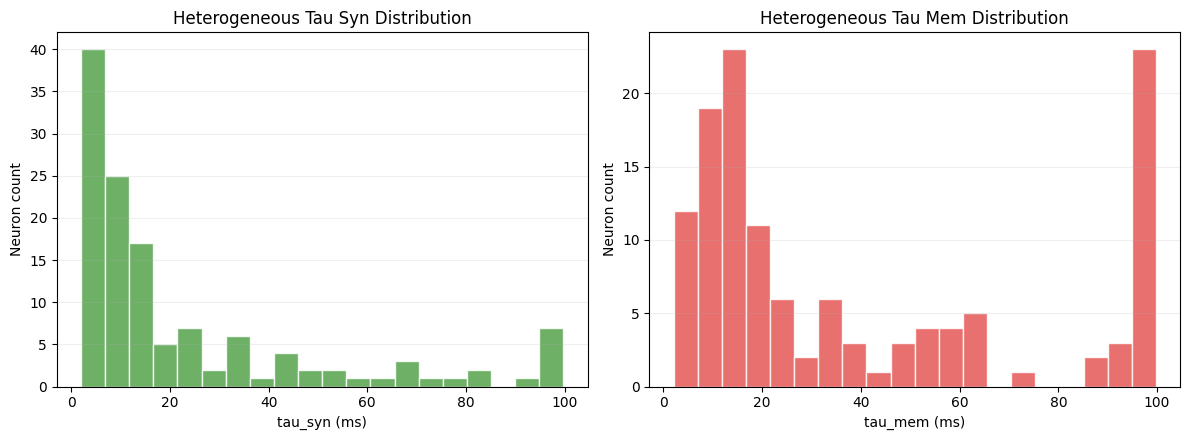

In [10]:
required_names = [
    "homogeneous_history",
    "heterogeneous_history",
    "training_results",
    "heterogeneous_alpha_after",
    "heterogeneous_beta_after",
    "heterogeneous_prms",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup cell plus both training cells before plotting performance and tau distributions."
    )

epochs = np.arange(1, len(homogeneous_history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(epochs, homogeneous_history["train_acc"], marker="o", label="Homogeneous train")
axes[0].plot(epochs, homogeneous_history["test_acc"], marker="o", linestyle="--", label="Homogeneous test")
axes[0].plot(epochs, heterogeneous_history["train_acc"], marker="o", label="Heterogeneous train")
axes[0].plot(epochs, heterogeneous_history["test_acc"], marker="o", linestyle="--", label="Heterogeneous test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Task Performance Across Epochs")
axes[0].grid(alpha=0.2)
axes[0].legend()

final_accs = [
    training_results["homogeneous"]["test_acc"],
    training_results["heterogeneous"]["test_acc"],
]
bars = axes[1].bar(
    ["Homogeneous", "Heterogeneous"],
    final_accs,
    color=["#4c78a8", "#f58518"],
    alpha=0.9,
    )
axes[1].set_ylabel("Final test accuracy")
axes[1].set_title("Final SHD Task Performance")
axes[1].set_ylim(0, max(final_accs) * 1.25 if max(final_accs) > 0 else 1.0)
axes[1].grid(axis="y", alpha=0.2)
for bar, value in zip(bars, final_accs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

tau_syn_ms = decay_to_tau(
    heterogeneous_alpha_after.detach().cpu().numpy().ravel(),
    heterogeneous_prms["time_step"],
) * 1e3
tau_mem_ms = decay_to_tau(
    heterogeneous_beta_after.detach().cpu().numpy().ravel(),
    heterogeneous_prms["time_step"],
) * 1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(tau_syn_ms, bins=20, color="#54a24b", alpha=0.85, edgecolor="white")
axes[0].set_title("Heterogeneous Tau Syn Distribution")
axes[0].set_xlabel("tau_syn (ms)")
axes[0].set_ylabel("Neuron count")
axes[0].grid(axis="y", alpha=0.2)

axes[1].hist(tau_mem_ms, bins=20, color="#e45756", alpha=0.85, edgecolor="white")
axes[1].set_title("Heterogeneous Tau Mem Distribution")
axes[1].set_xlabel("tau_mem (ms)")
axes[1].set_ylabel("Neuron count")
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [11]:
import json

# Compute homogeneous tau arrays from the trained alpha/beta scalars.
hom_tau_syn_ms = decay_to_tau(
    homogeneous_alpha_after.detach().cpu().numpy().ravel(),
    homogeneous_prms["time_step"],
) * 1e3

hom_tau_mem_ms = decay_to_tau(
    homogeneous_beta_after.detach().cpu().numpy().ravel(),
    homogeneous_prms["time_step"],
) * 1e3

tau_distributions = {
    "run_config": RUN_CONFIG,
    "homogeneous": {
        "initial": homogeneous_before,
        "final": homogeneous_after,
        "tau_syn_ms": hom_tau_syn_ms.tolist(),
        "tau_mem_ms": hom_tau_mem_ms.tolist(),
    },
    "heterogeneous": {
        "initial": heterogeneous_before,
        "final": heterogeneous_after,
        "tau_syn_ms": tau_syn_ms.tolist(),
        "tau_mem_ms": tau_mem_ms.tolist(),
    },
}

save_path = PROJECT_ROOT / "Tau from 15 epoch run.json"
with open(save_path, "w") as f:
    json.dump(tau_distributions, f, indent=2)

print(f"Saved tau distributions to: {save_path}")

Saved tau distributions to: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Tau from 15 epoch run.json


## M-Information Calculation

Run the setup cell and both training cells first. The next cell computes Gaussian $\mathcal{M}$-information from the trained hidden membrane trajectories of the homogeneous and heterogeneous `RSNN` models.

In [12]:
required_names = [
    "training_results",
    "homogeneous_model",
    "heterogeneous_model",
    "homogeneous_prms",
    "heterogeneous_prms",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the setup cell and both training cells before computing M-information."
    )

m_downsample_stride = RUN_CONFIG.get("m_downsample_stride", 4)

homogeneous_m = estimate_m_info(
    homogeneous_model,
    prms=homogeneous_prms,
    path=SHD_TEST,
    subset_size=RUN_CONFIG["m_subset_size"],
    max_batches=RUN_CONFIG["m_batches"],
    downsample_stride=m_downsample_stride,
 )
heterogeneous_m = estimate_m_info(
    heterogeneous_model,
    prms=heterogeneous_prms,
    path=SHD_TEST,
    subset_size=RUN_CONFIG["m_subset_size"],
    max_batches=RUN_CONFIG["m_batches"],
    downsample_stride=m_downsample_stride,
 )

comparison_results = deepcopy(training_results)
comparison_results["homogeneous"]["M_bits"] = homogeneous_m["M_bits"]
comparison_results["homogeneous"]["M_meta"] = homogeneous_m
comparison_results["heterogeneous"]["M_bits"] = heterogeneous_m["M_bits"]
comparison_results["heterogeneous"]["M_meta"] = heterogeneous_m

print(comparison_results)

{'homogeneous': {'test_acc': 0.5485865724381626, 'mean_abs_alpha_change': 0.0034407973289489746, 'mean_abs_beta_change': 0.07571810483932495, 'initial_summary': {'alpha_unique': 1, 'beta_unique': 1, 'tau_syn_ms_min': 10.000006010359865, 'tau_syn_ms_max': 10.000006010359865, 'tau_mem_ms_min': 19.999997015687487, 'tau_mem_ms_max': 19.999997015687487}, 'final_summary': {'alpha_unique': 1, 'beta_unique': 1, 'tau_syn_ms_min': 10.778350927342288, 'tau_syn_ms_max': 10.778350927342288, 'tau_mem_ms_min': 4.725265049788249, 'tau_mem_ms_max': 4.725265049788249}, 'M_bits': 0.006526029965758795, 'M_meta': {'W_bits': 9.775306757917905, 'M_bits': 0.006526029965758795, 'subset_size': 6, 'samples': 96000, 'downsample_stride': 4, 'optimiser': 'Newton'}}, 'heterogeneous': {'test_acc': 0.6086572438162544, 'mean_abs_alpha_change': 0.035302650183439255, 'mean_abs_beta_change': 0.01743004098534584, 'initial_summary': {'alpha_unique': 128, 'beta_unique': 128, 'tau_syn_ms_min': 0.5985968411043763, 'tau_syn_ms_

## M-Information Plot


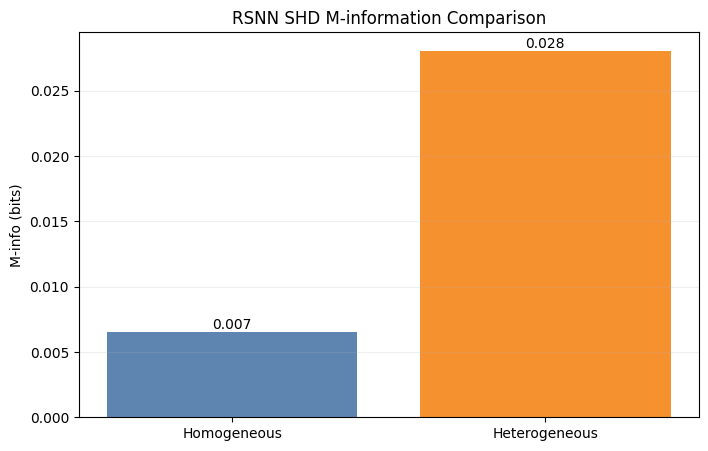

In [ ]:
required_names = ["comparison_results"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "No Calculation"
    )

labels = ["Homogeneous", "Heterogeneous"]
m_values = [comparison_results["homogeneous"]["M_bits"], comparison_results["heterogeneous"]["M_bits"]]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, m_values, color=["#4c78a8", "#f58518"], alpha=0.9)
plt.ylabel("M-info (bits)")
plt.title("RSNN SHD M-information Comparison")
plt.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, m_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
plt.show()

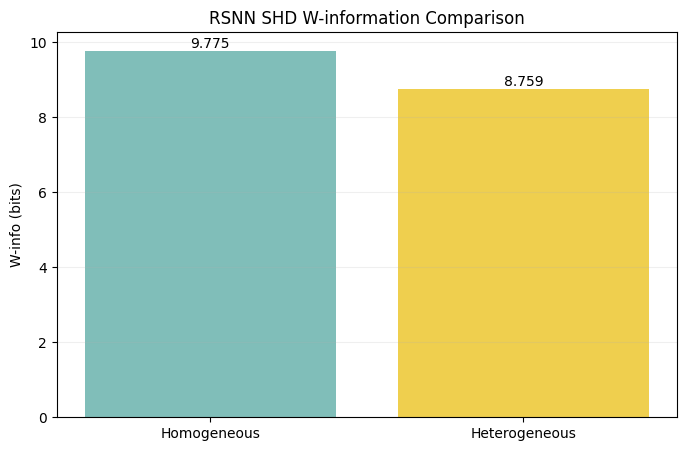

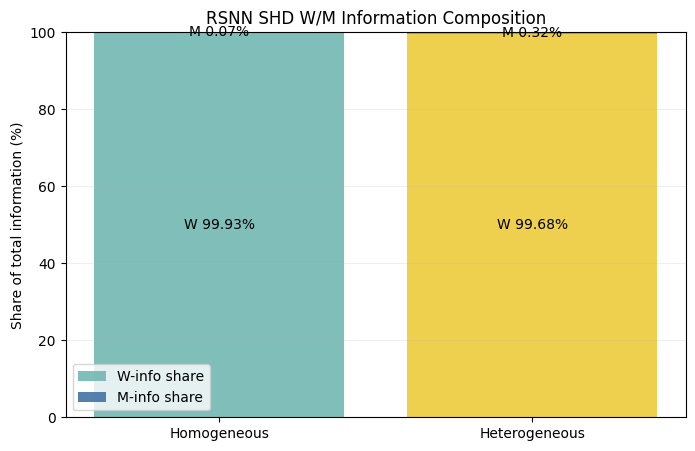

In [14]:
required_names = ["comparison_results"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the M-information cells first so the W-information and percentage plots use the current results."
    )

labels = ["Homogeneous", "Heterogeneous"]
w_values = [
    comparison_results["homogeneous"]["M_meta"]["W_bits"],
    comparison_results["heterogeneous"]["M_meta"]["W_bits"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, w_values, color=["#72b7b2", "#eeca3b"], alpha=0.9)
plt.ylabel("W-info (bits)")
plt.title("RSNN SHD W-information Comparison")
plt.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, w_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
plt.show()

m_values = [
    comparison_results["homogeneous"]["M_bits"],
    comparison_results["heterogeneous"]["M_bits"],
]
total_values = [m + w for m, w in zip(m_values, w_values)]
w_percent = [100.0 * w / total for w, total in zip(w_values, total_values)]
m_percent = [100.0 * m / total for m, total in zip(m_values, total_values)]

plt.figure(figsize=(8, 5))
bars_w = plt.bar(labels, w_percent, color=["#72b7b2", "#eeca3b"], alpha=0.9, label="W-info share")
bars_m = plt.bar(labels, m_percent, bottom=w_percent, color=["#4c78a8", "#f58518"], alpha=0.95, label="M-info share")
plt.ylabel("Share of total information (%)")
plt.title("RSNN SHD W/M Information Composition")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.2)
plt.legend()
for label, w_pct, m_pct in zip(labels, w_percent, m_percent):
    plt.text(labels.index(label), w_pct / 2, f"W {w_pct:.2f}%", ha="center", va="center", color="black")
    plt.text(labels.index(label), w_pct + m_pct / 2, f"M {m_pct:.2f}%", ha="center", va="center", color="black")
plt.show()

## Hidden State Manifold Visualization

This section compares the internal representations learned by the homogeneous and heterogeneous RSNNs by projecting their hidden-layer activity into 2D.

**Method:** After training, a batch of SHD test samples is passed through each network. The membrane potential $V(t)$ of the hidden recurrent layer is recorded at the **final timestep** of each audio sample, yielding a vector in $\mathbb{R}^{128}$ per sample. These are then reduced to 2D with **PCA** (or UMAP if installed) and plotted as a scatter coloured by the true digit label (classes 0–19).

A more clustered, class-separated manifold suggests the network has learned more discriminative internal representations.

Collected: hom=(512, 128), het=(512, 128)  reducer=PCA


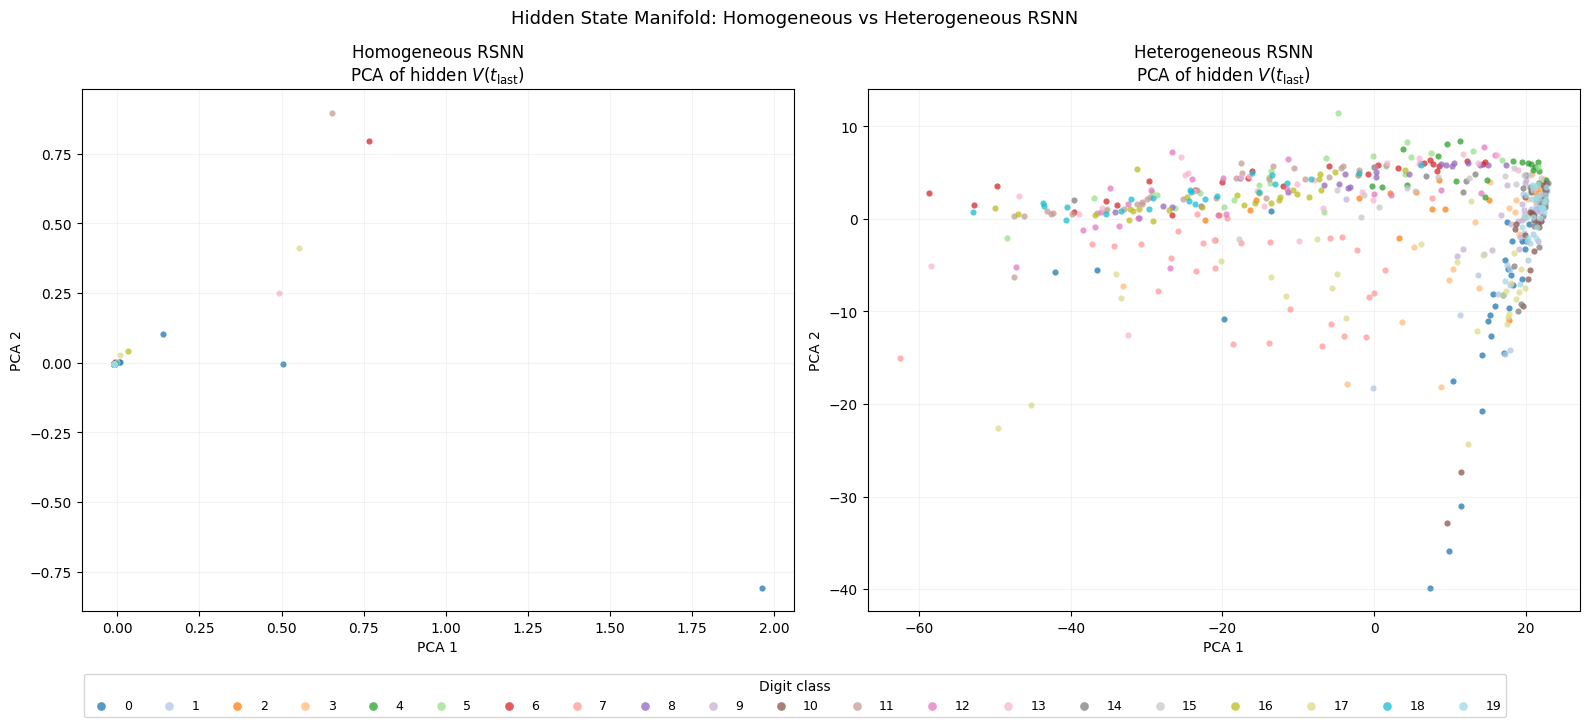

PCA 2-component explained variance — hom: 65.2%, het: 95.6%


In [ ]:
required_names = [
    "homogeneous_model",
    "heterogeneous_model",
    "homogeneous_prms",
    "heterogeneous_prms",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "No training in memory"
    )

from sklearn.decomposition import PCA

try:
    from umap import UMAP as _UMAP
    _HAVE_UMAP = True
except ImportError:
    _HAVE_UMAP = False

REDUCER_NAME = "UMAP" if _HAVE_UMAP else "PCA"
MANIFOLD_BATCHES = 8  # ~512 samples (8 × 64)
N_CLASSES = len(homogeneous_prms["class_list"])


@torch.no_grad()
def _collect_last_timestep_hidden(model, prms, path, max_batches):
    """Return (hidden_vecs [N, H], labels [N]) for up to max_batches test batches."""
    hidden_chunks, label_chunks = [], []
    with shd_open(path) as (units, times, labels):
        for batch_idx, (x, y) in enumerate(
            shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)
        ):
            if batch_idx >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            # layer_recs[0][1]: hidden membrane potentials, shape [batch, time, neurons]
            mem_last = layer_recs[0][1][:, -1, :].detach().cpu().numpy()
            hidden_chunks.append(mem_last)
            label_chunks.append(y.cpu().numpy())
    return np.concatenate(hidden_chunks, axis=0), np.concatenate(label_chunks, axis=0)


hom_hidden, hom_labels = _collect_last_timestep_hidden(
    homogeneous_model, homogeneous_prms, SHD_TEST, max_batches=MANIFOLD_BATCHES
)
het_hidden, het_labels = _collect_last_timestep_hidden(
    heterogeneous_model, heterogeneous_prms, SHD_TEST, max_batches=MANIFOLD_BATCHES
)
print(f"Collected: hom={hom_hidden.shape}, het={het_hidden.shape}  reducer={REDUCER_NAME}")


def _make_reducer():
    if _HAVE_UMAP:
        return _UMAP(n_components=2, random_state=42, n_jobs=1)
    return PCA(n_components=2)


hom_2d = _make_reducer().fit_transform(hom_hidden)
het_2d = _make_reducer().fit_transform(het_hidden)

# ── Plot ─────────────────────────────────────────────────────────────────────
cmap = plt.colormaps["tab20"]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, lbls, title in [
    (axes[0], hom_2d, hom_labels, "Homogeneous RSNN"),
    (axes[1], het_2d, het_labels, "Heterogeneous RSNN"),
]:
    for cls in range(N_CLASSES):
        mask = lbls == cls
        if mask.sum() == 0:
            continue
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            color=cmap(cls / max(N_CLASSES - 1, 1)),
            label=str(cls),
            s=20,
            alpha=0.75,
            linewidths=0,
        )
    ax.set_title(f"{title}\n{REDUCER_NAME} of hidden $V(t_{{\\mathrm{{last}}}})$", fontsize=12)
    ax.set_xlabel(f"{REDUCER_NAME} 1")
    ax.set_ylabel(f"{REDUCER_NAME} 2")
    ax.grid(alpha=0.15)

handles, label_text = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    label_text,
    title="Digit class",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=N_CLASSES,
    fontsize=9,
    markerscale=1.4,
)
plt.suptitle(
    "Hidden State Manifold: Homogeneous vs Heterogeneous RSNN", fontsize=13
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

if not _HAVE_UMAP:
    # Report explained variance for PCA so the reader can gauge information retention
    pca_hom = PCA(n_components=2).fit(hom_hidden)
    pca_het = PCA(n_components=2).fit(het_hidden)
    print(
        f"PCA 2-component explained variance — "
        f"hom: {pca_hom.explained_variance_ratio_.sum():.1%}, "
        f"het: {pca_het.explained_variance_ratio_.sum():.1%}"
    )